# ARIMA — Model Experiment
**Dataset:** Monthly Labor Market (`monthly_labor_market.csv`)  
**Target:** `EMPLOY`  
**Horizon:** 12 months  
**Split:** 80% train / next 12 months test  
**Metrics:** MAE, MSE  
**Model:** ARIMA(2,2,2)

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp/xdg-cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

In [2]:
TARGET = "EMPLOY"

df = pd.read_csv("../data/processed/monthly_labor_market.csv")
df.rename(columns={"date": "ds"}, inplace=True)
df["ds"] = pd.to_datetime(df["ds"], format="%Y:%m")
df = df.dropna(how="all", subset=df.columns[1:])
df = df.ffill()
df = df.dropna()

split = int(len(df) * 0.8)
train_df = df.iloc[:split].copy()
test_df = df.iloc[split:split + 12].copy()
y_true = test_df[TARGET].values

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
df.head()

Train shape: (596, 9)
Test shape: (12, 9)


,ds,POP,LFC,LFPART,RUC,EMPLOY,H,HG,HS
300,1964-01-01,123560.0,72356.0,58.5594,5.6,57487.0,50.8,92.4,39.3
301,1964-02-01,123707.0,72683.0,58.7542,5.4,57753.0,51.5,95.3,39.4
302,1964-03-01,123857.0,72713.0,58.7072,5.4,57897.0,51.5,95.1,39.4
303,1964-04-01,124019.0,73274.0,59.0829,5.3,57922.0,51.7,95.2,39.6
304,1964-05-01,124204.0,73395.0,59.0923,5.1,58089.0,51.9,95.6,39.6


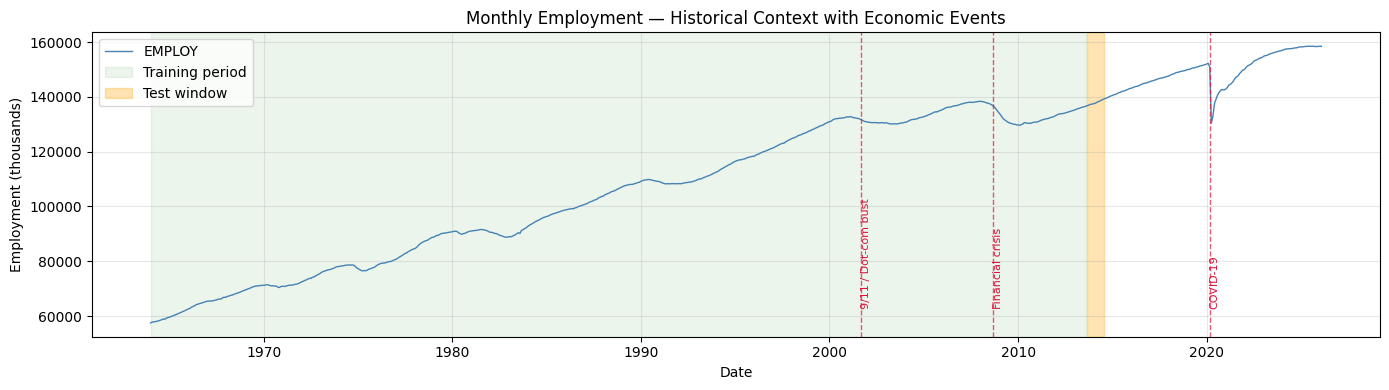

In [3]:
EVENTS = {
    "2001-09-01": "9/11 / Dot-com bust",
    "2008-09-01": "Financial crisis",
    "2020-03-01": "COVID-19",
}

y_max = df[TARGET].max()
y_min = df[TARGET].min()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["ds"], df[TARGET], color="steelblue", linewidth=1, label=TARGET)
ax.axvspan(train_df["ds"].iloc[0], train_df["ds"].iloc[-1], alpha=0.08, color="green", label="Training period")
ax.axvspan(test_df["ds"].iloc[0], test_df["ds"].iloc[-1], alpha=0.3, color="orange", label="Test window")

for date, label in EVENTS.items():
    ts = pd.Timestamp(date)
    ax.axvline(ts, color="crimson", linestyle="--", linewidth=1, alpha=0.7)
    ax.text(ts, y_min + (y_max - y_min) * 0.05, label, rotation=90, fontsize=8, color="crimson", va="bottom")

ax.set_title("Monthly Employment — Historical Context with Economic Events")
ax.set_xlabel("Date")
ax.set_ylabel("Employment (thousands)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
model = ARIMA(train_df[TARGET].astype(float).values, order=(2, 2, 2)).fit()
arima_pred = np.asarray(model.forecast(12))

print("Shape:", arima_pred.shape)
print("Prediction:", np.round(arima_pred, 2))

Shape: (12,)
Prediction: [136838.58 137040.41 137238.56 137439.26 137638.   137838.26 138037.35
 138237.34 138436.63 138636.46 138835.88 139035.62]


In [5]:
arima_mae = mean_absolute_error(y_true, arima_pred)
arima_mse = mean_squared_error(y_true, arima_pred)

print(f"ARIMA(2,2,2)  MAE: {arima_mae:.2f}")
print(f"ARIMA(2,2,2)  MSE: {arima_mse:.2f}")

ARIMA(2,2,2)  MAE: 103.21
ARIMA(2,2,2)  MSE: 16708.52


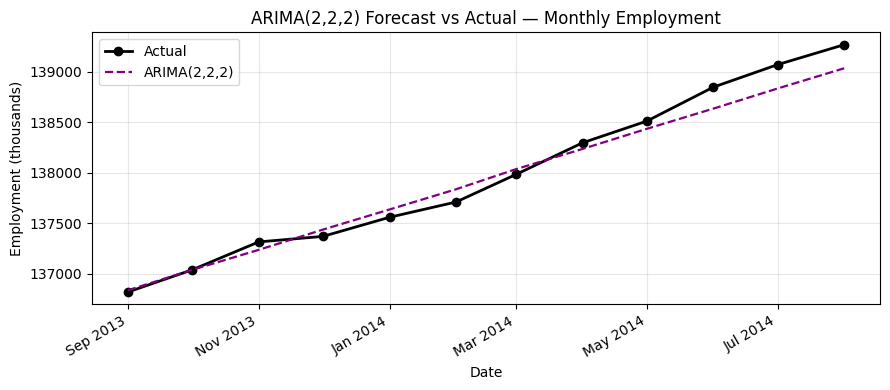

In [6]:
forecast_dates = test_df["ds"].values
save_dir = Path("../results/report_assets/figures")
save_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(forecast_dates, y_true, color="black", marker="o", label="Actual", linewidth=2)
ax.plot(forecast_dates, arima_pred, linestyle="--", color="purple", label="ARIMA(2,2,2)", linewidth=1.6)
ax.set_title("ARIMA(2,2,2) Forecast vs Actual — Monthly Employment")
ax.set_xlabel("Date")
ax.set_ylabel("Employment (thousands)")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
plt.tight_layout()
fig.savefig(save_dir / "arima_forecast.png", dpi=200)
plt.show()

In [7]:
print(f"\n{'Model':<16} {'MAE':>10} {'MSE':>14}")
print("-" * 42)
print(f"{'ARIMA(2,2,2)':<16} {arima_mae:>10.2f} {arima_mse:>14.2f}")


Model                   MAE            MSE
------------------------------------------
ARIMA(2,2,2)         103.21       16708.52
